# 05 - Indicadores y evolución 2024-2026 (Ejercicios 7 y 8)

Lee las tablas de indicadores `ind_*` de `data/processed/taxi.duckdb` (generadas por `scripts/build_db.py`
desde `sql/07_indicadores.sql`) en **modo solo lectura** — así puede convivir con Metabase — y ejecuta
las consultas de evolución de `sql/08_validacion_2025.sql` sobre Parquet. Las gráficas se guardan en
`docs/img/evol_*.png` y se usan en `docs/08_analisis_completo.md`.

In [1]:
import sys
sys.path.insert(0, '../scripts')
from pathlib import Path
import lab_db
import matplotlib.pyplot as plt
import pandas as pd

db = lab_db.conectar(lab_db.DB_MATERIALIZADA, read_only=True)
pq = lab_db.conectar()
IMG = Path('../docs/img')
ANIOS = {2024: '#4c72b0', 2025: '#dd8452', 2026: '#55a868'}
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
ind = lambda t: db.execute(f'SELECT * FROM {t}').df()
def guardar(fig, n): fig.savefig(IMG / f'{n}.png', bbox_inches='tight'); plt.show()
print([r[0] for r in db.execute('SHOW TABLES').fetchall()])

['ind_aeropuertos', 'ind_borough_origen', 'ind_calidad_datos', 'ind_cuota_congestion', 'ind_demanda_horaria', 'ind_demanda_mensual', 'ind_ingreso_por_viaje', 'ind_mix_pago', 'ind_plataformas', 'ind_propina_tarjeta', 'ind_resumen_anual', 'ind_velocidad_horaria', 'trips', 'trips_clean', 'zones']


## I1 - Demanda: viajes por día por mes, superponiendo años

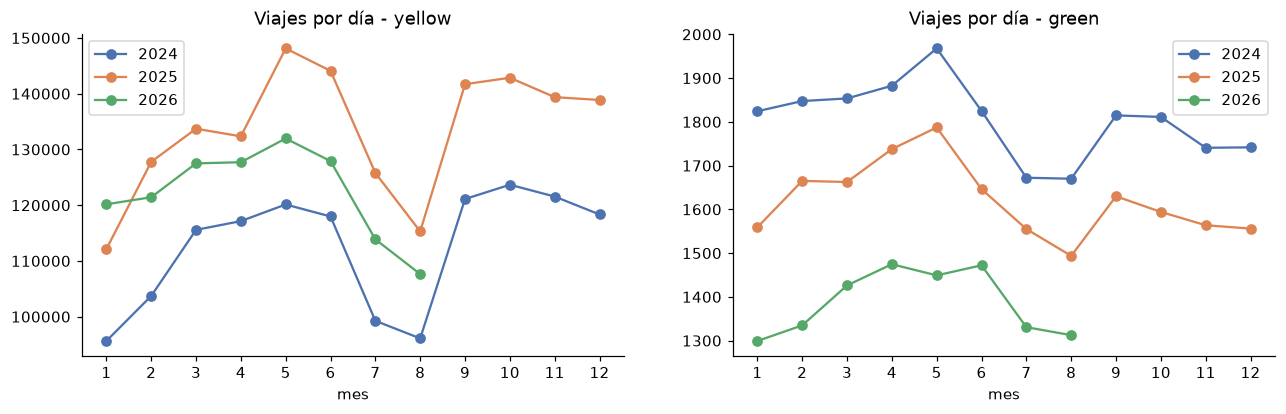

In [2]:
d = ind('ind_demanda_mensual')
fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))
for ax, tipo in zip(axes, ['yellow', 'green']):
    for anio, g in d[d.taxi_type == tipo].groupby('anio'):
        ax.plot(g.mes, g.viajes_por_dia, marker='o', color=ANIOS[anio], label=str(anio))
    ax.set_title(f'Viajes por día - {tipo}'); ax.set_xticks(range(1, 13)); ax.set_xlabel('mes'); ax.legend()
guardar(fig, 'evol_i1_demanda')

In [3]:
v = lab_db.ejecutar(pq, lab_db.consulta('q8_08_cambio_mensual_interanual', '../sql/08_validacion_2025.sql').sql)[0]
v

,taxi_type,mes,v2024,v2025,v2026,var_25_vs_24,var_26_vs_25
0,yellow,1,95633.0,112104.0,120158.0,17.2,7.2
1,yellow,2,103708.0,127769.0,121424.0,23.2,-5.0
2,yellow,3,115569.0,133718.0,127498.0,15.7,-4.7
3,yellow,4,117143.0,132352.0,127708.0,13.0,-3.5
4,yellow,5,120124.0,148124.0,131962.0,23.3,-10.9
5,yellow,6,117973.0,144099.0,127908.0,22.1,-11.2
6,yellow,7,99255.0,125773.0,113874.0,26.7,-9.5
7,yellow,8,96103.0,115293.0,107636.0,20.0,-6.6
8,yellow,9,121101.0,141701.0,NaN,17.0,NaN
9,yellow,10,123670.0,142861.0,NaN,15.5,NaN


## Comparación anual en el mismo período (ene-ago)

In [4]:
r = ind('ind_resumen_anual'); r

,anio,taxi_type,viajes_ene_ago,viajes_por_dia,total_promedio_usd,distancia_mediana_mi,duracion_mediana_min,velocidad_mediana_mph,pct_tarjeta,propina_pct_tarjeta
0,2024,yellow,25127229,102980.0,28.33,1.80,12.8,9.53,76.04,22.15
1,2024,green,407649,1671.0,23.74,1.98,12.0,10.40,68.01,20.77
2,2025,yellow,28305202,116482.0,28.32,1.90,13.1,9.69,68.99,22.31
3,2025,green,362901,1493.0,24.83,2.04,12.5,10.31,70.08,20.58
4,2026,yellow,27884915,114753.0,30.18,1.95,14.2,9.31,65.72,21.63
5,2026,green,309437,1273.0,25.32,2.15,13.3,10.06,66.55,21.15


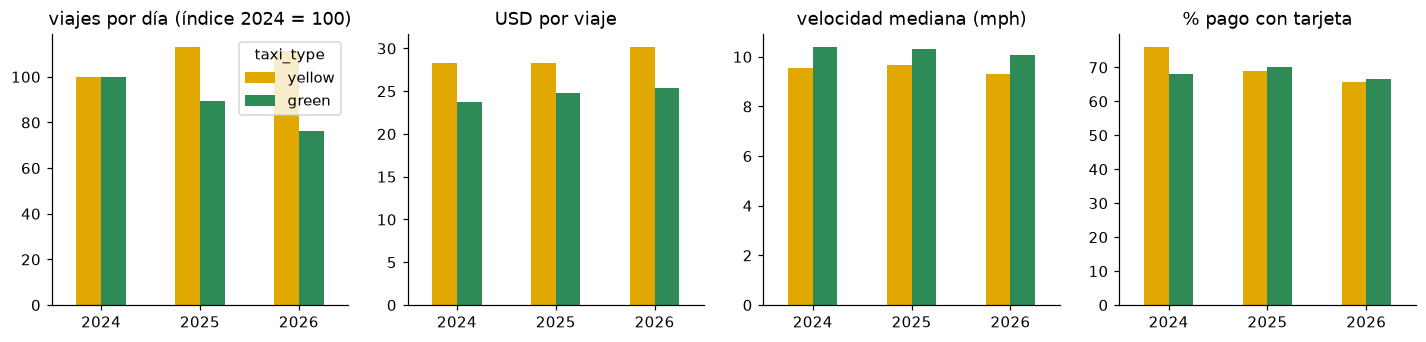

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.2))
for ax, col, tit in zip(axes, ['viajes_por_dia', 'total_promedio_usd', 'velocidad_mediana_mph', 'pct_tarjeta'],
                        ['viajes por día', 'USD por viaje', 'velocidad mediana (mph)', '% pago con tarjeta']):
    p = r.pivot(index='anio', columns='taxi_type', values=col)
    if col == 'viajes_por_dia':
        p = p / p.iloc[0] * 100; tit = 'viajes por día (índice 2024 = 100)'
    p[['yellow', 'green']].plot.bar(ax=ax, color=['#e0a800', '#2e8b57'], legend=(col == 'viajes_por_dia'), rot=0)
    ax.set_title(tit); ax.set_xlabel('')
guardar(fig, 'evol_resumen_anual')

## I2 / I9 - Precio y cuota de congestión

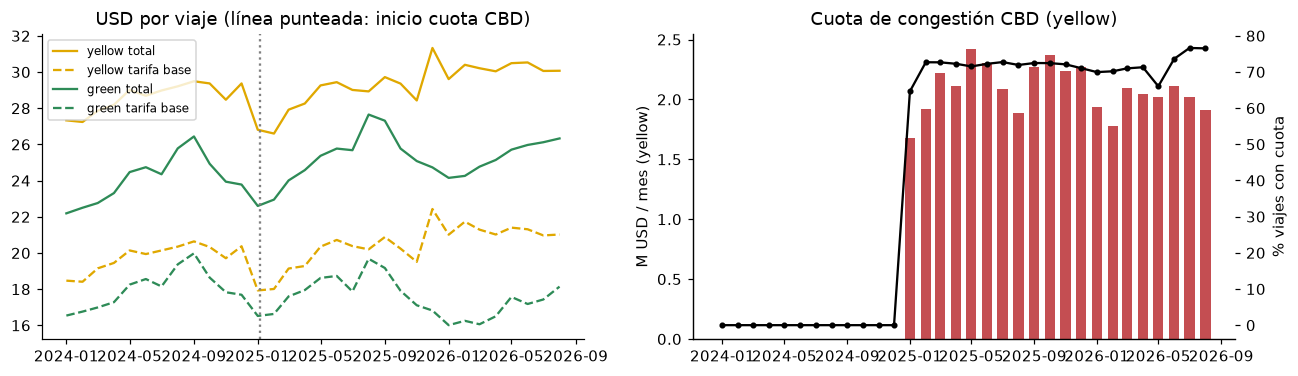

In [6]:
p = ind('ind_ingreso_por_viaje'); c = ind('ind_cuota_congestion')
fig, axes = plt.subplots(1, 2, figsize=(14, 3.6))
for tipo, col in [('yellow', '#e0a800'), ('green', '#2e8b57')]:
    g = p[p.taxi_type == tipo]
    axes[0].plot(g.periodo, g.total_promedio_usd, color=col, label=f'{tipo} total')
    axes[0].plot(g.periodo, g.tarifa_promedio_usd, color=col, ls='--', label=f'{tipo} tarifa base')
axes[0].axvline(pd.Timestamp('2025-01-05'), color='gray', ls=':'); axes[0].legend(fontsize=8); axes[0].set_title('USD por viaje (línea punteada: inicio cuota CBD)')
y = c[c.taxi_type == 'yellow']
axes[1].bar(y.periodo, y.recaudacion_usd / 1e6, width=20, color='#c44e52'); axes[1].set_ylabel('M USD / mes (yellow)')
ax2 = axes[1].twinx(); ax2.plot(y.periodo, y.pct_viajes_con_cuota, color='black', marker='.'); ax2.set_ylabel('% viajes con cuota')
axes[1].set_title('Cuota de congestión CBD (yellow)')
guardar(fig, 'evol_i2_i9_precio_cbd')

## I4 - Velocidad por hora y velocidad en la zona CBD

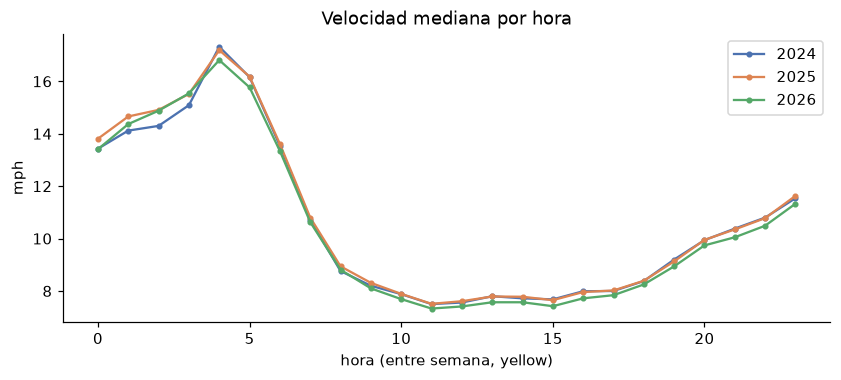

,anio,viajes,velocidad_mediana_mph,duracion_mediana_min,distancia_mediana_mi
0,2024,12872997,8.35,13.2,1.63
1,2025,13584933,8.34,13.2,1.64
2,2026,13050702,7.94,14.2,1.66


In [7]:
vel = ind('ind_velocidad_horaria')
fig, ax = plt.subplots(figsize=(9, 3.4))
for anio, g in vel.groupby('anio'):
    ax.plot(g.hora, g.velocidad_mediana_mph, marker='.', color=ANIOS[anio], label=str(anio))
ax.set_xlabel('hora (entre semana, yellow)'); ax.set_ylabel('mph'); ax.legend(); ax.set_title('Velocidad mediana por hora')
guardar(fig, 'evol_i4_velocidad')
lab_db.ejecutar(pq, lab_db.consulta('q8_07_velocidad_zona_cbd', '../sql/08_validacion_2025.sql').sql)[0]

## I5 / I10 / I11 - Pagos, calidad y plataformas

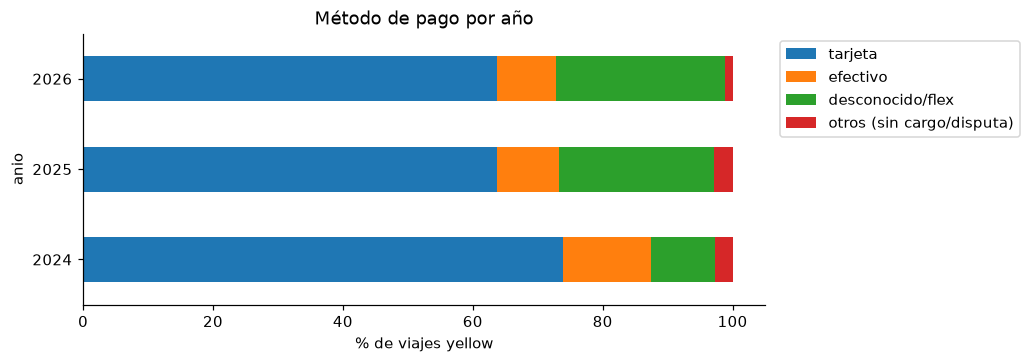

metodo_pago,desconocido/flex,efectivo,otros (sin cargo/disputa),tarjeta
anio,,,,
2024,9.94,13.46,2.64,73.97
2025,23.83,9.55,2.88,63.74
2026,25.98,9.12,1.14,63.77


In [8]:
m = ind('ind_mix_pago'); m = m[m.taxi_type == 'yellow'].groupby(['anio', 'metodo_pago']).viajes.sum().unstack()
m = (m.div(m.sum(axis=1), axis=0) * 100).round(2)
fig, ax = plt.subplots(figsize=(8, 3.2))
m[['tarjeta', 'efectivo', 'desconocido/flex', 'otros (sin cargo/disputa)']].plot.barh(stacked=True, ax=ax)
ax.set_xlabel('% de viajes yellow'); ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left'); ax.set_title('Método de pago por año')
guardar(fig, 'evol_i5_pago')
m

In [9]:
ind('ind_plataformas').query("taxi_type == 'yellow'")

,periodo,anio,mes,taxi_type,origen,viajes,pct
2,2026-06-01,2026,6,yellow,Uber (HV0003),927698,24.18
3,2026-06-01,2026,6,yellow,calle/sin dato,2824068,73.60
4,2026-06-01,2026,6,yellow,otras apps/despacho,85482,2.23
7,2026-07-01,2026,7,yellow,Uber (HV0003),739048,20.94
8,2026-07-01,2026,7,yellow,calle/sin dato,2560692,72.54
9,2026-07-01,2026,7,yellow,otras apps/despacho,230369,6.53
13,2026-08-01,2026,8,yellow,Lyft (HV0005),181233,5.43
14,2026-08-01,2026,8,yellow,Uber (HV0003),628774,18.84
15,2026-08-01,2026,8,yellow,calle/sin dato,2415867,72.40
16,2026-08-01,2026,8,yellow,otras apps/despacho,110842,3.32


## I7 / I8 - Aeropuertos y boroughs

In [10]:
ind('ind_aeropuertos').query("segmento == 'aeropuerto'")

,anio,taxi_type,segmento,viajes,pct_viajes,pct_ingresos,total_promedio_usd
0,2024,green,aeropuerto,25789,4.25,8.26,46.77
2,2024,yellow,aeropuerto,3955294,10.11,27.89,78.97
4,2025,green,aeropuerto,20455,3.77,7.33,48.81
6,2025,yellow,aeropuerto,3858814,8.86,24.21,78.80
8,2026,green,aeropuerto,10641,3.44,6.57,48.39
10,2026,yellow,aeropuerto,2273124,8.15,21.06,77.96


In [11]:
ind('ind_borough_origen').pivot_table(index='serie', columns='borough', values='pct').round(2)

borough,Bronx,Brooklyn,Manhattan,Otros/Desconocido,Queens
serie,,,,,
green 2024,1.06,13.08,61.31,0.09,24.47
green 2025,1.54,13.91,62.07,0.09,22.39
green 2026,2.26,14.95,60.63,0.13,22.03
yellow 2024,0.29,1.40,88.86,0.30,9.16
yellow 2025,0.77,3.33,86.31,0.19,9.40
yellow 2026,0.77,3.59,86.72,0.13,8.79


## Conclusiones (8.5 / 8.6)

Ver `docs/08_analisis_completo.md`: (1) el taxi amarillo tuvo un salto de demanda en 2025 (+13% ene-ago) y
se contrajo levemente en 2026, mientras el verde cae de forma sostenida (~−11% y −15% anual); (2) el precio
efectivo subió en 2025 por la cuota CBD y en 2026 por la tarifa base, sin mejora de velocidad en la zona
CBD; (3) los pagos con tarjeta bajan y crecen los viajes sin datos de taxímetro, en paralelo con la entrada
de plataformas (Uber/Lyft) como origen de la solicitud; (4) los aeropuertos pierden peso en los ingresos.